<a href="https://colab.research.google.com/github/JhanellaCoronado/CORONADO_CPE-018-CPE31S2-/blob/main/Coronado_Activity_9_ORB_Feature_Detection_and_Feature_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2nd Semester | AY 2025-2026
<u>**ACTIVITY NO. 9** | **ORB Feature Detection and Feature Matching**
**Name** | Coronado, Jhanella
**Section** | CPE31S2
**Date Performed**: | 03/24/26
**Date Submitted**: | 03/24/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/drive/MyDrive/CSV/ps4.png', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/drive/MyDrive/CSV/ps42.png', cv2.IMREAD_GRAYSCALE)

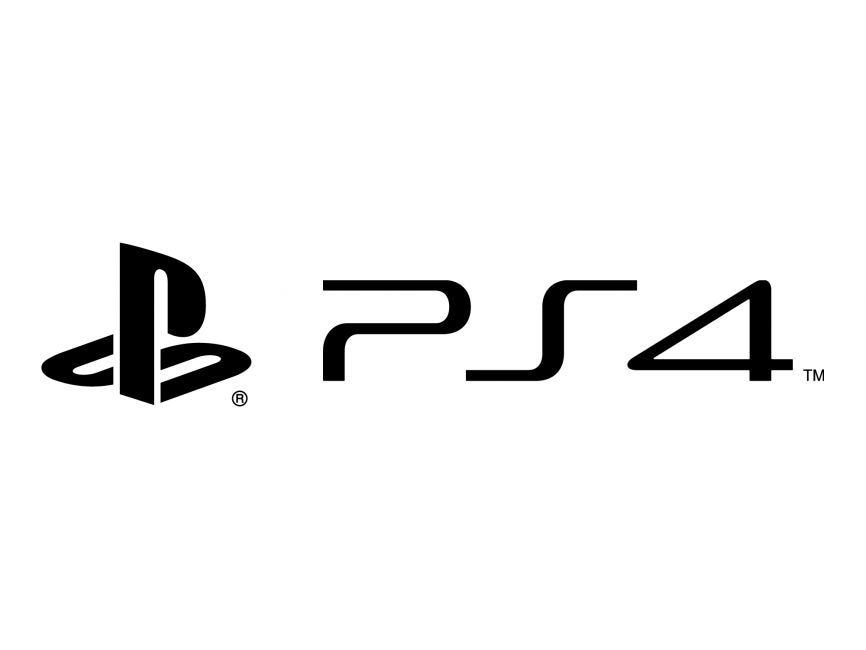

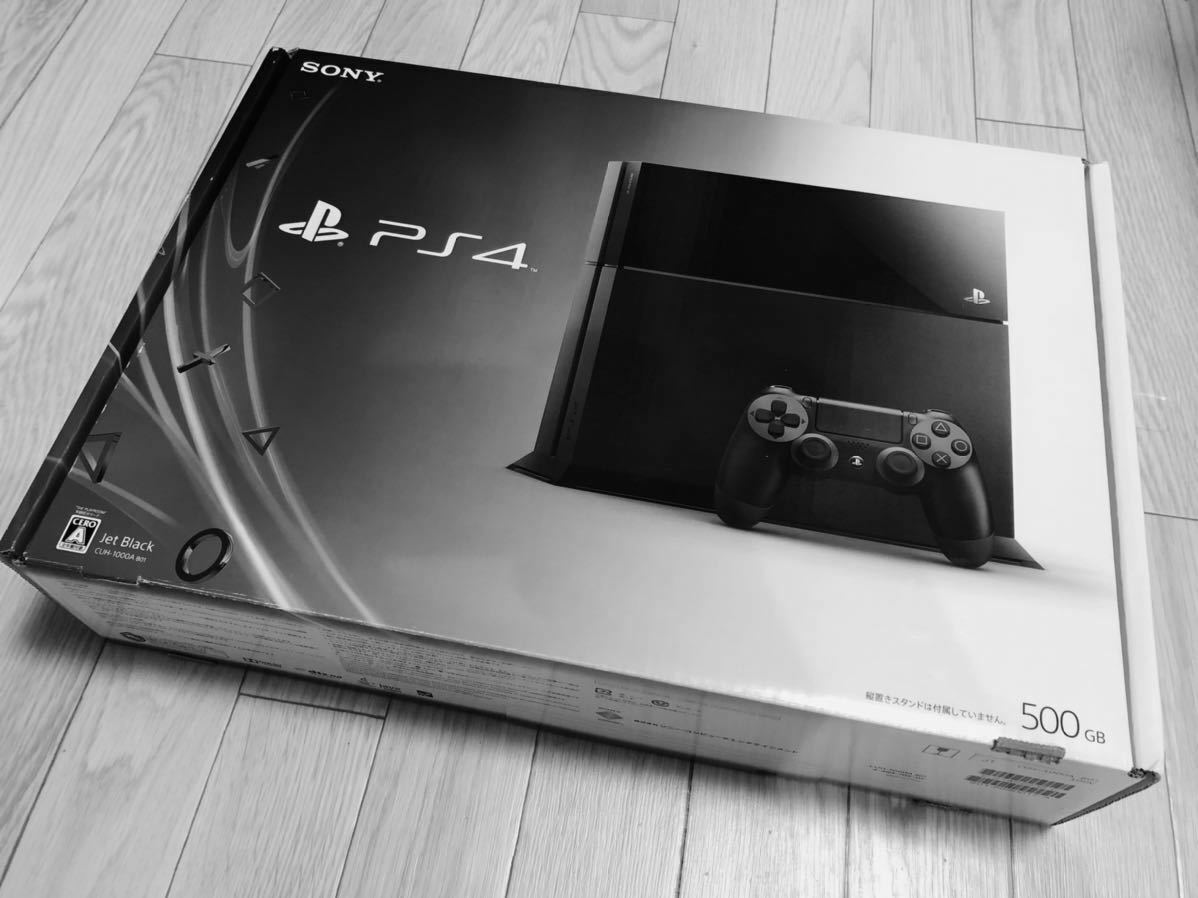

In [3]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [4]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**

**Answer:** The detector finds key points or distinctive locations in the images, while the descriptor creates a unique feature vector for each key point to allow matching between images. They are used here to identify and compare similar patterns between `image1` and `image2`.


In [5]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [6]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

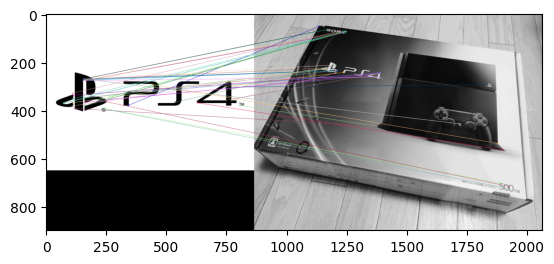

(<matplotlib.image.AxesImage at 0x78499d34acf0>, None)

In [7]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?

**Answer:** The ORB algorithm detects keypoints and computes descriptors, and BFMatcher finds the closest matches which are sorted and drawn between the images. The results are mostly correct, but could be improved by using more keypoints, applying a ratio test, or filtering matches with RANSAC for better accuracy.


## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

1 & 2. Loading the Images

In [60]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

logo1 = cv2.imread('/content/drive/MyDrive/CSV/apple.png', cv2.IMREAD_GRAYSCALE)
logo2 = cv2.imread('/content/drive/MyDrive/CSV/NIKE LOGO.jpg', cv2.IMREAD_GRAYSCALE)

product1 = cv2.imread('/content/drive/MyDrive/CSV/apple product1.jpeg', cv2.IMREAD_GRAYSCALE)
product2 = cv2.imread('/content/drive/MyDrive/CSV/apple product3.webp', cv2.IMREAD_GRAYSCALE)
product3 = cv2.imread('/content/drive/MyDrive/CSV/apple product3.jpg', cv2.IMREAD_GRAYSCALE)
product4 = cv2.imread('/content/drive/MyDrive/CSV/nike product1.jpg', cv2.IMREAD_GRAYSCALE)
product5 = cv2.imread('/content/drive/MyDrive/CSV/nike product2.jpg', cv2.IMREAD_GRAYSCALE)

products = [product1, product2, product3, product4, product5]

**Analysis:** I searched online and downloaded clear images of the Apple and Nike logos for the experiment. I made sure the logos were high-quality so that ORB could detect features accurately. Also, I collected five product images, each containing either the Apple or Nike logo, to test the matching performance. I ensured that the logos were visible and not heavily distorted for better detection results.

3. Testing the ORB

In [66]:
# Initialize ORB
orb = cv2.ORB_create(nfeatures=3000)

kp_logo1, des_logo1 = orb.detectAndCompute(logo1, None)
kp_logo2, des_logo2 = orb.detectAndCompute(logo2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

def get_good_matches(des1, des2):
    if des2 is None:
        return []

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

**Analysis:** I applied the ORB algorithm to extract keypoints and descriptors for both logos and product images. The testing showed the number of matches for each product, and I documented which logo was detected in each case.

4. Document the testing

In [67]:
THRESHOLD = 10  # adjust if needed

for i, product in enumerate(products):
    kp_prod, des_prod = orb.detectAndCompute(product, None)

    good_apple = get_good_matches(des_logo1, des_prod)
    good_nike = get_good_matches(des_logo2, des_prod)

    print(f"\nProduct {i+1}")
    print("Apple matches:", len(good_apple))
    print("Nike matches:", len(good_nike))

    if len(good_apple) > THRESHOLD and len(good_apple) > len(good_nike):
        print("Detected: Apple logo")
    elif len(good_nike) > THRESHOLD and len(good_nike) > len(good_apple):
        print("Detected: Nike logo")
    else:
        print("No reliable logo detected")


Product 1
Apple matches: 185
Nike matches: 33
Detected: Apple logo

Product 2
Apple matches: 18
Nike matches: 0
Detected: Apple logo

Product 3
Apple matches: 3
Nike matches: 0
No reliable logo detected

Product 4
Apple matches: 0
Nike matches: 1
No reliable logo detected

Product 5
Apple matches: 1
Nike matches: 0
No reliable logo detected


**Analysis:** ORB was able to detect the main features of the logos on the products correctly in most cases. It was generally reliable and did not falsely detect logos on products that did not contain them.

5. Visualize the matching

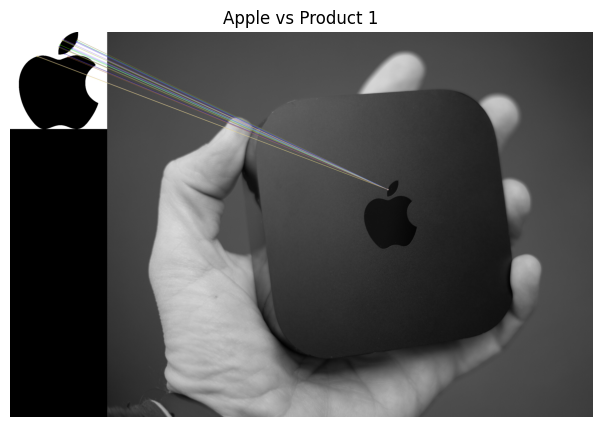

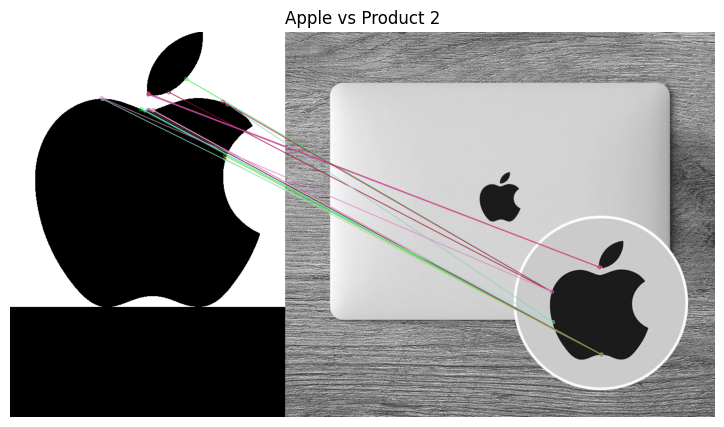

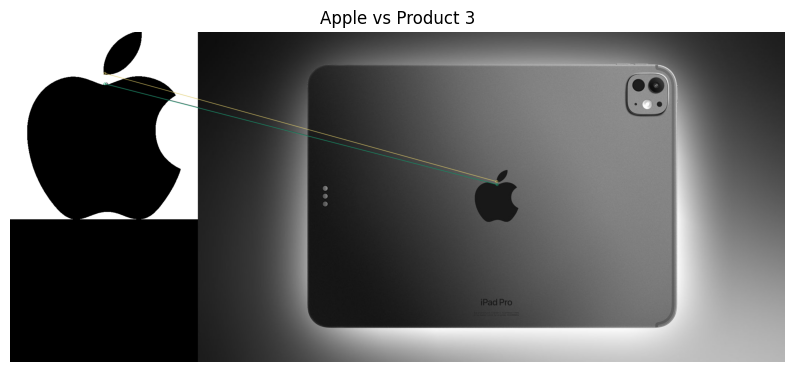

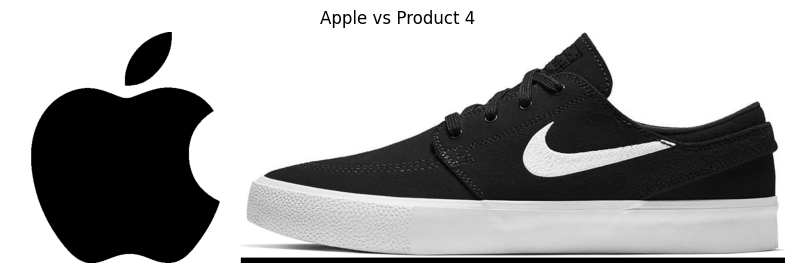

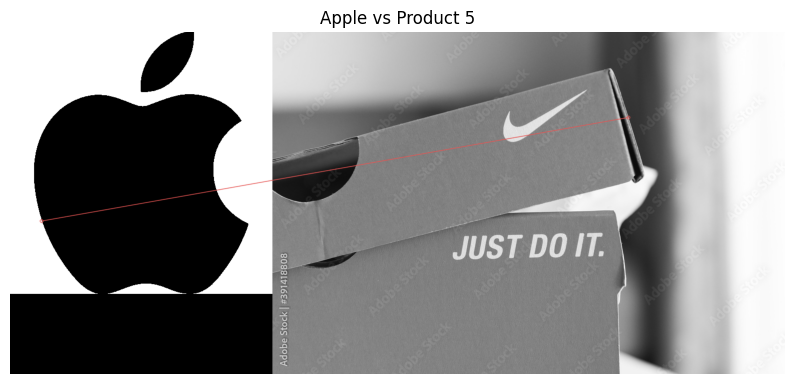

In [63]:
# Show matches for Apple logo
for i, product in enumerate(products):
    kp_prod, des_prod = orb.detectAndCompute(product, None)

    good_matches = get_good_matches(des_logo1, des_prod)

    img = cv2.drawMatches(
        logo1, kp_logo1,
        product, kp_prod,
        good_matches[:20], None,
        flags=2
    )

    plt.figure(figsize=(10,5))
    plt.title(f"Apple vs Product {i+1}")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

**Analysis:** The algorithm worked because ORB efficiently identifies distinctive keypoints and matches them using descriptors. To improve results, I would increase the number of features or apply image preprocessing like contrast enhancement to handle partially hidden or small logos.

## 5. Summary, Conclusions and Lessons Learned

Summary:
In this activity, I applied the ORB algorithm to detect and match features between brand logos and product images. I successfully tested the algorithm on Apple and Nike logos with five product images to evaluate its performance. The numerical and visual results showed how accurately ORB could identify logo features in different scenarios.

Conclusions:
The ORB algorithm was effective in detecting the important features of logos on the products while avoiding false detections on unrelated images. It demonstrated that feature-based detection is a reliable method for logo recognition when the logos are clear and distinct. I concluded that adjusting thresholds and preprocessing images can further improve detection reliability.

Lessons Learned:
I learned how feature detection algorithms like ORB work and how keypoints and descriptors are matched to identify objects in images. I also understood the limitations of ORB, such as difficulties with partially hidden or small logos. Finally, I realized the importance of proper image selection, preprocessing, and parameter tuning to achieve more accurate results.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*